In [54]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image


from pc import PS
from modules import ADC,DAC,CHIP
from cimCommand import CMD,CmdData,Packet
from cimCommand.singleCmdInfo import *

from util import plot_v_cond

In [55]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=3),init=True)
chip.set_device_cfg(deviceType=0)

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 52698
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: flt           	字节码: 09 00 00 0f ff
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 00 80
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 01 00
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: cim_reset     	字节码: 0b 00 00 00 01
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: cim_ss        	字节码: 0d 00 00 00 01
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: ser_para_sel  	字节码: 0e 00 00 00 01

指令完整字节码:  55aa010900000fff
send_packets收到55bb或55cc用时: 0.000103 seconds
收到信息: 4 bb550000
指令完整字节码:  55aa010100000080
send_packets收到55bb或55cc用时: 0.000145 seconds
收到信息: 4 bb550000
指令完整字节码:  55aa010100000100
send_packets收到55bb或55cc用时: 0.000149 seconds
收到信息: 4 bb550000
指令完整字节码:  55aa010b00000001
send_packets收到55bb或55cc用时: 0.000154 seconds
收到信息: 4 bb550000
指令完整字节码:  55aa010d00000001
send_packets收到55bb或55cc用时: 0.000165 seconds
收到信息: 4 bb550000
指令完整字节码:  

In [48]:
delay = 100
delay2 = 100
pkts=Packet()
pkts.append_cmdlist([
    CMD(OP_BANK_CFG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_CIM_DATA_CFG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(REG_CLK_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(LATCH_CLK_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_ADC_AVRG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_DAC_AVRG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_ROW_PULSE_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_COL_PULSE_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_CIM_RSTN_DONE_DELAY_CYC,command_data=CmdData(delay)),

    CMD(CIM_RSTN_CYC,command_data=CmdData(delay2)),
    CMD(LATCH_CLK_CYC,command_data=CmdData(delay2)),
    CMD(REG_CLK_CYC,command_data=CmdData(delay2)),
    CMD(LATCH_CYC,command_data=CmdData(delay2)),
],mode=1)
chip.ps.send_packets(pkts)

模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_bank_cfg_done_delay_cyc    	字节码: 1e 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_cim_data_cfg_done_delay_cyc	字节码: 1f 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: reg_clk_done_delay_cyc        	字节码: 20 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: latch_clk_done_delay_cyc      	字节码: 21 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_adc_avrg_done_delay_cyc    	字节码: 22 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_dac_cfg_done_delay_cyc     	字节码: 23 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_row_pulse_done_delay_cyc   	字节码: 24 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_col_pulse_done_delay_cyc   	字节码: 25 00 00 00 64
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_cim_rstn_done_delay_cyc    	字节码: 26 00 0

In [56]:
# ins_data=[CMD(PL_DAC_V,command_data=CmdData((i+DAC_INFO.INDEX_START)<<16)) for i in range(1)]
# chip.execute_ins(ins_data=ins_data,ins_ram_start=0)
need_read = np.zeros((256,256),dtype=bool)
need_read[120,:128] = 1
voltage_base = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)

pkts=Packet()
pkts.append_cmdlist([
    CMD(INS_RUN_TIME_L32),
],mode=2)
chip.ps.send_packets(pkts,recv=False)

message = chip.ps.receive_packet(4)

tmp = message.hex()[6:8]+message.hex()[4:6]+message.hex()[2:4] + message.hex()[0:2]
print(tmp)
data = int(tmp, 16)
print(data*1e-8)

模式: 1
	帧头:     	字节码: 55 aa 01
	指令: gain	字节码: 10 00 00 00 01

指令完整字节码:  55aa011000000001
send_packets收到55bb或55cc用时: 0.000012 seconds
收到信息: 4 bb550000
模式: 4
	帧头:               	字节码: 55 aa 04
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 0d
	指令: pl_dac_v      	字节码: 03 00 00 00
	指令: pl_dac_v      	字节码: 03 01 00 00
	指令: pl_dac_v      	字节码: 03 02 00 00
	指令: pl_dac_v      	字节码: 03 03 00 00
	指令: pl_dac_v      	字节码: 03 04 00 00
	指令: pl_dac_v      	字节码: 03 05 00 00
	指令: pl_dac_v      	字节码: 03 06 00 00
	指令: pl_dac_v      	字节码: 03 07 00 00
	指令: pl_dac_v      	字节码: 03 08 00 00
	指令: pl_dac_v      	字节码: 03 09 00 00
	指令: pl_dac_v      	字节码: 03 0a 00 00
	指令: pl_dac_v      	字节码: 03 0b 00 00
	指令: pl_exit       	字节码: 0b 00 00 00
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 80 00

指令完整字节码:  55aa040000000d03000000030100000302000003030000030400000305000003060000030700000308000003090000030a0000030b00000b000000
send_packets收到55bb或55cc用时: 0.000100 seconds
收到信息: 4 bb5500

In [ ]:
pkts=Packet()
pkts.append_single([
    CMD(PL_RAM_ADDR,command_data=CmdData(128)),
    CMD(PL_DATA_LENGTH,command_data=CmdData(1))
],mode=6)
chip.ps.send_packets(pkts,recv=False)

tia16_length = 64
tia_num = 16
tia_length = 4
# 接收信息, num条dout_ram值, 每条dout_ram长为256/8=32B
message = chip.ps.receive_packet(32)

In [5]:
delay = 10
delay2 = 100
pkts=Packet()
pkts.append_cmdlist([
    CMD(OP_BANK_CFG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_CIM_DATA_CFG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(REG_CLK_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(LATCH_CLK_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_ADC_AVRG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_DAC_AVRG_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_ROW_PULSE_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_COL_PULSE_DONE_DELAY_CYC,command_data=CmdData(delay)),
    CMD(OP_CIM_RSTN_DONE_DELAY_CYC,command_data=CmdData(delay)),

    CMD(CIM_RSTN_CYC,command_data=CmdData(delay2)),
    CMD(LATCH_CLK_CYC,command_data=CmdData(delay2)),
    CMD(REG_CLK_CYC,command_data=CmdData(delay2)),
    CMD(LATCH_CYC,command_data=CmdData(delay2)),
],mode=1)
chip.ps.send_packets(pkts)

模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_bank_cfg_done_delay_cyc    	字节码: 1e 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_cim_data_cfg_done_delay_cyc	字节码: 1f 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: reg_clk_done_delay_cyc        	字节码: 20 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: latch_clk_done_delay_cyc      	字节码: 21 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_adc_avrg_done_delay_cyc    	字节码: 22 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_dac_cfg_done_delay_cyc     	字节码: 23 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_row_pulse_done_delay_cyc   	字节码: 24 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_col_pulse_done_delay_cyc   	字节码: 25 00 00 00 0a
模式: 1
	帧头:                               	字节码: 55 aa 01
	指令: op_cim_rstn_done_delay_cyc    	字节码: 26 00 0

In [6]:
need_read = np.zeros((256,256),dtype=bool)
need_read[120,:] = 1
data = chip.get_data(crossbar=need_read,from_row=True)

模式: 5
	帧头:               	字节码: 55 aa 05
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 21
	指令: pl_data       	字节码: 00 00 00 00
	指令: pl_data       	字节码: 10 00 00 00
	指令: pl_data       	字节码: 00 00 00 01
	指令: pl_data       	字节码: 00 00 00 02
	指令: pl_data       	字节码: 00 00 00 04
	指令: pl_data       	字节码: 00 00 00 08
	指令: pl_data       	字节码: 00 00 00 10
	指令: pl_data       	字节码: 00 00 00 20
	指令: pl_data       	字节码: 00 00 00 40
	指令: pl_data       	字节码: 00 00 00 80
	指令: pl_data       	字节码: 00 00 01 00
	指令: pl_data       	字节码: 00 00 02 00
	指令: pl_data       	字节码: 00 00 04 00
	指令: pl_data       	字节码: 00 00 08 00
	指令: pl_data       	字节码: 00 00 10 00
	指令: pl_data       	字节码: 00 00 20 00
	指令: pl_data       	字节码: 00 00 40 00
	指令: pl_data       	字节码: 00 00 80 00
	指令: pl_data       	字节码: 00 01 00 00
	指令: pl_data       	字节码: 00 02 00 00
	指令: pl_data       	字节码: 00 04 00 00
	指令: pl_data       	字节码: 00 08 00 00
	指令: pl_data       	字节码: 00 10 00 00
	指令: pl_data       	字节码: 00 20 00 00
	指令: pl_da

In [3]:
need_read = np.zeros((256,256),dtype=bool)
need_read[120,:128] = 1
voltage_base = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
# voltage = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
# cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)

模式: 1
	帧头:     	字节码: 55 aa 01
	指令: gain	字节码: 10 00 00 00 01

指令完整字节码:  55aa011000000001
send_packets收到55bb或55cc用时: 0.000396 seconds
收到信息: 4 bb550000
模式: 4
	帧头:               	字节码: 55 aa 04
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 0d
	指令: pl_dac_v      	字节码: 03 00 00 00
	指令: pl_dac_v      	字节码: 03 01 00 00
	指令: pl_dac_v      	字节码: 03 02 00 00
	指令: pl_dac_v      	字节码: 03 03 00 00
	指令: pl_dac_v      	字节码: 03 04 00 00
	指令: pl_dac_v      	字节码: 03 05 00 00
	指令: pl_dac_v      	字节码: 03 06 00 00
	指令: pl_dac_v      	字节码: 03 07 00 00
	指令: pl_dac_v      	字节码: 03 08 00 00
	指令: pl_dac_v      	字节码: 03 09 00 00
	指令: pl_dac_v      	字节码: 03 0a 00 00
	指令: pl_dac_v      	字节码: 03 0b 00 00
	指令: pl_exit       	字节码: 0b 00 00 00
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 80 00

指令完整字节码:  55aa040000000d03000000030100000302000003030000030400000305000003060000030700000308000003090000030a0000030b00000b000000
send_packets收到55bb或55cc用时: 0.000365 seconds
收到信息: 4 bb5500

In [16]:
message = chip.ps.receive_packet(4)

receive_packet:接收超时!


In [15]:
ins_data=[CMD(PL_DAC_V,command_data=CmdData((i+DAC_INFO.INDEX_START)<<16)) for i in range(1)]
chip.execute_ins(ins_data=ins_data,ins_ram_start=0)

模式: 4
	帧头:               	字节码: 55 aa 04
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 02
	指令: pl_dac_v      	字节码: 03 00 00 00
	指令: pl_exit       	字节码: 0b 00 00 00
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 80 00

指令完整字节码:  55aa0400000002030000000b000000
send_packets收到55bb或55cc用时: 0.000795 seconds
收到信息: 4 bb550000
指令完整字节码:  55aa010100008000
send_packets收到55bb或55cc用时: 0.005481 seconds
收到信息: 4 cc550000


In [ ]:
pkts=Packet()
pkts.append_cmdlist([
    CMD(INS_RUN_TIME_L32),
    # CMD(INS_RUN_TIME_H32),
],mode=2)
chip.ps.send_packets(pkts,recv=False)

message = chip.ps.receive_packet(4)

tmp = message.hex()[6:8]+message.hex()[4:6]+message.hex()[2:4] + message.hex()[0:2]
print(tmp)
data = int(tmp, 16)
print(data*1e-8)

message = chip.ps.receive_packet(4)
print(message.hex())
data = int(message.hex(), 16)
print(data)

In [4]:
import time

pkts=Packet()
pkts.append_cmdlist([
    CMD(INS_RUN_TIME_L32),
],mode=3)

start_time = time.perf_counter()
chip.ps.send_packets(pkts,recv=False)
message = chip.ps.receive_packet(3)
end_time = time.perf_counter()
elapsed_time = end_time - start_time  
print(f"用时: {elapsed_time:.6f} seconds")                         

模式: 3
	帧头:                 	字节码: 55 aa 03

指令完整字节码:  55aa03
收到信息: 3 55aa03
receive_packet收到消息用时: 0.000758 seconds
用时: 0.001034 seconds


In [7]:
pkts=Packet()
pkts.append_cmdlist([
    CMD(INS_RUN_TIME_L32),
    CMD(INS_RUN_TIME_H32),
],mode=2)
chip.ps.send_packets(pkts,recv=False)

message = chip.ps.receive_packet(4)

tmp = message.hex()[6:8]+message.hex()[4:6]+message.hex()[2:4] + message.hex()[0:2]
print(tmp)
data = int(tmp, 16)
print(data*1e-8)

message = chip.ps.receive_packet(4)
print(message.hex())
data = int(message.hex(), 16)
print(data)

模式: 2
	帧头:                 	字节码: 55 aa 02
	指令: ins_run_time_l32	字节码: 2b
模式: 2
	帧头:                 	字节码: 55 aa 02
	指令: ins_run_time_h32	字节码: 2c

指令完整字节码:  55aa022b
指令完整字节码:  55aa022c
收到信息: 4 8d000000
receive_packet收到消息用时: 0.000554 seconds
0000008d
1.41e-06
收到信息: 4 00000000
receive_packet收到消息用时: 0.000364 seconds
00000000
0


In [8]:
result = []
for i in range(40):
    voltage_base = chip.read_point2(data=data, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point2(data=data, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
    result.append(cond_sub_base[120,:])

# result = []
# for i in range(40):
#     voltage_base = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
#     voltage = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
#     cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
#     result.append(cond_sub_base[120,:])

模式: 1
	帧头:     	字节码: 55 aa 01
	指令: gain	字节码: 10 00 00 00 01

指令完整字节码:  55aa011000000001
send_packets收到55bb或55cc用时: 0.000990 seconds
收到信息: 4 bb550000
模式: 4
	帧头:               	字节码: 55 aa 04
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 0c
	指令: pl_dac_v      	字节码: 03 00 00 00
	指令: pl_dac_v      	字节码: 03 01 00 00
	指令: pl_dac_v      	字节码: 03 02 00 00
	指令: pl_dac_v      	字节码: 03 03 00 00
	指令: pl_dac_v      	字节码: 03 04 00 00
	指令: pl_dac_v      	字节码: 03 05 00 00
	指令: pl_dac_v      	字节码: 03 06 00 00
	指令: pl_dac_v      	字节码: 03 07 00 00
	指令: pl_dac_v      	字节码: 03 08 00 00
	指令: pl_dac_v      	字节码: 03 09 00 00
	指令: pl_dac_v      	字节码: 03 0a 00 00
	指令: pl_dac_v      	字节码: 03 0b 00 00
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: ins_num       	字节码: 1c 00 00 00 0c
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 80 00

指令完整字节码:  55aa040000000c03000000030100000302000003030000030400000305000003060000030700000308000003090000030a0000030b0000
send_packets收到55bb或55cc

0
0
0
0
1
0
0
0
0
0
1
0
1
0
1
0
2
0
1
1
1
2
0
1
1
0
2
2
0
1
0
1
1
2
2
0
1
0
1
1
27


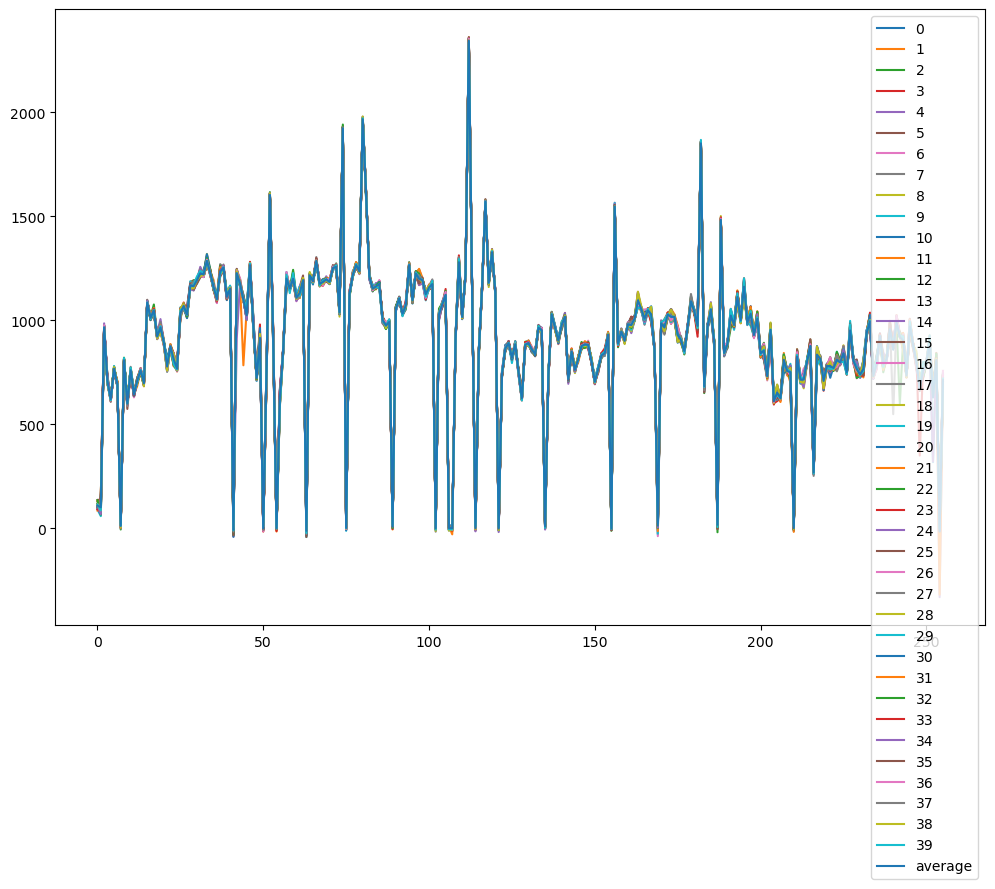

In [9]:
average = np.zeros((1,256))
for k,v in enumerate(result):
    average += v
average /=40

sum = 0
for k,v in enumerate(result):
    tmp = np.sum(abs(v-average)>50)
    print(tmp)
    sum +=tmp

print(sum)
plt.figure(figsize=(12,8))
for k,v in enumerate(result):
    plt.plot(v,label=f"{k}")

plt.plot(average[0,:],label = "average")
plt.legend()
plt.show()